<a href="https://colab.research.google.com/github/jtan21at/996.ICU/blob/master/PureConv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 14.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 393kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.18MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.0MB/s]


In [ ]:
batch = next(iter(train_loader))
batch[0].shape

torch.Size([32, 1, 28, 28])

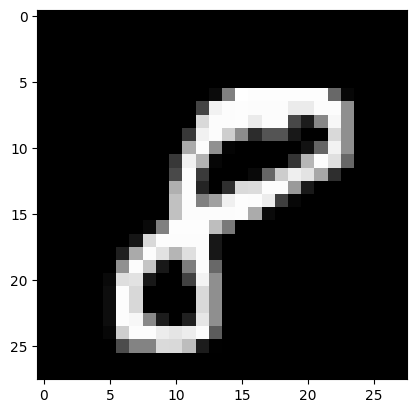

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(batch[0][0][0], cmap='gray')

In [ ]:
batch[1][0]

tensor(8)

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class PureConvNet(nn.Module):
  def __init__(self, num_classes=10):
    super().__init__()
    self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
    self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
    self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
    self.pool = nn.MaxPool2d(2, 2)
    self.fc1 = nn.Linear(128 * 3 * 3, 512)
    self.fc2 = nn.Linear(512, num_classes)
    self.dropout = nn.Dropout(0.25)

  def forward(self, x):
    x = self.pool(F.relu(self.conv1(x)))
    x = self.pool(F.relu(self.conv2(x)))
    x = self.pool(F.relu(self.conv3(x)))
    x = x.view(-1, 128 * 3 * 3)
    x = F.relu(self.fc1(x))
    x = self.dropout(x)
    return self.fc2(x)

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = PureConvNet().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
model.train()
n_epochs = 10

for epoch in range(n_epochs):
  running_loss = 0.0
  for batch_idx, (data, target) in enumerate(train_loader):
    data, target = data.to(device), target.to(device)
    optimizer.zero_grad()
    outputs = model(data)
    loss = criterion(outputs, target)
    loss.backward()
    optimizer.step()
    running_loss += loss.item()

  print(f'Epoch {epoch + 1}, Loss: {running_loss / len(train_loader)}')

Epoch 1, Loss: 0.11620455720525545
Epoch 2, Loss: 0.042809263114646695
Epoch 3, Loss: 0.032128203159263166
Epoch 4, Loss: 0.023759199605435665
Epoch 5, Loss: 0.02147425604502717
Epoch 6, Loss: 0.018363812827769714
Epoch 7, Loss: 0.015413041390561693
Epoch 8, Loss: 0.013811414400874189
Epoch 9, Loss: 0.012354001744601082
Epoch 10, Loss: 0.011169080744420131


In [ ]:
model.eval()
correct = 0
total = 0
with torch.no_grad():
  for data, target in test_loader:
    data, target = data.to(device), target.to(device)
    outputs = model(data)
    _, predicted = outputs.max(1)
    total += target.size(0)
    correct += (predicted == target).sum().item()

print(f'Accuracy: {correct / total}')

Accuracy: 0.989
